In [21]:
#Leer capa
import geopandas as gpd
from itables import init_notebook_mode, show

# Activamos el modo interactivo para todo el cuaderno
init_notebook_mode(all_interactive=False)

ruta_capa = r'C:/O/OneDrive - SERINGTEC/zecl/PROYECTOS/RUBIALES/SHP/Zonificacion/ZonManAmbRub_20260113/ZonManAmbRub_20260113.shp'
capa_gpd = gpd.read_file(ruta_capa)

,FID_Zonifi,EXPEDIENTE,ZONMANEJO,NOMENCLAT,AREA_HA,OBSERV,SHAPE_Leng,Shape_Le_1,Shape_Area,FID_Fishne,Id,geometry
0,1,LAM0019,0.0,Con Restricción,4.831138,Con Restricción,1020.577815,1020.577815,48311.381593,148,0,"POLYGON ((5170872.279 1965459.277, 5170879.664..."
1,2,LAM0019,0.0,Con Restricción,0.397331,Con Restricción,262.706054,262.706054,3973.314349,149,0,"POLYGON ((5172058.457 1965614.723, 5172146.644..."
2,3,LAM0019,0.0,Con Restricción,15.397176,Con Restricción,4203.374851,4203.374851,153971.764375,147,0,"POLYGON ((5170198.125 1965178.234, 5170192.339..."
3,3,LAM0019,0.0,Con Restricción,15.397176,Con Restricción,4203.374851,4203.374851,153971.764375,148,0,"POLYGON ((5170198.125 1965178.234, 5170197.805..."
4,4,LAM0019,0.0,Con Restricción,0.005587,Con Restricción,65.891584,65.891584,55.865045,148,0,"POLYGON ((5171034.667 1965624.953, 5171030.603..."


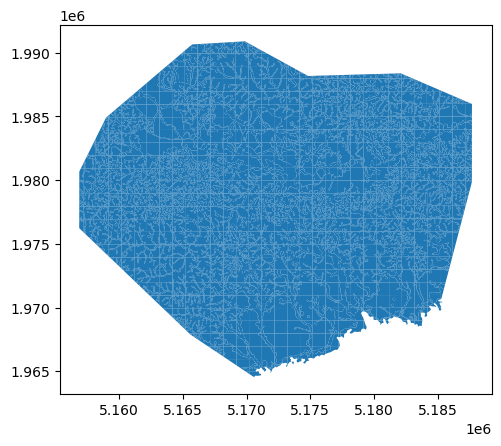

In [23]:
capa_gpd.plot()
capa_gpd.head()

In [24]:
#Resumen estadístico rápido por campo
capa_gpd['NOMENCLAT'].describe()

count               17145
unique                  3
top       Con Restricción
freq                11502
Name: NOMENCLAT, dtype: object

In [27]:
#Resumen de los valores que contiene un campo
capa_gpd['NOMENCLAT'].value_counts()

NOMENCLAT
Con Restricción    11502
Intervención        3206
Exclusión           2437
Name: count, dtype: int64

In [50]:
#SCRIPT PARA UNIR LAS 2 ZONIFICACIONES Y EVALUAR EL CAMBIO EN LAS ZONAS DE EXCLUSIÓN
#Cargar las capas de zonificación anterior y actual
ruta_zma_anterior = r'C:/O/OneDrive - SERINGTEC/zecl/PROYECTOS/RUBIALES/SHP/Zonificacion/ZonManAmbRub_20260113/ZonManAmbRub_20260113.shp'
ruta_zma_actual = r'C:/O/OneDrive - SERINGTEC/zecl/PROYECTOS/RUBIALES/SHP/Zonificacion/ZonManAmbRub_20260410/ZonManAmbRub_20260410.shp'
ruta_capa_salida = r'C:/O/OneDrive - SERINGTEC/zecl/PROYECTOS/RUBIALES/SHP/Analisis/ZMA_20260113_vs_20260410.shp'
#Leer las capas
capa_zma_anterior = gpd.read_file(ruta_zma_anterior)
capa_zma_actual = gpd.read_file(ruta_zma_actual)
#Reproyectar las capas al EPSG: 3117
capa_zma_anterior = capa_zma_anterior.to_crs(epsg=3117)
capa_zma_actual = capa_zma_actual.to_crs(epsg=3117)
#print(f"CRS ZMA Anterior: {capa_zma_anterior.crs.name}")
#print(f"CRS ZMA Actual: {capa_zma_actual.crs.name}")
#Unión entre las capas
union = gpd.overlay(capa_zma_anterior,capa_zma_actual, how='union')

KeyboardInterrupt: 

In [35]:
print(capa_zma_anterior.crs.to_authority())

('ESRI', '103599')


In [42]:
#Extracción de las áreas en donde había exclusión o hay exclusión
condicion = (union['NOMENCLAT_1'] == 'Exclusión') | (union['NOMENCLAT_2'] == 'Exclusión')
union_filtrada = union[condicion].copy()
len_union = len(union)
len_union_filtrada = len(union_filtrada)
print(f"Polígonos Unión: {len_union}")
print(f"Polígonos Unión Filtrada: {len_union_filtrada}")

Polígonos Unión: 77038
Polígonos Unión Filtrada: 29286


<Axes: >

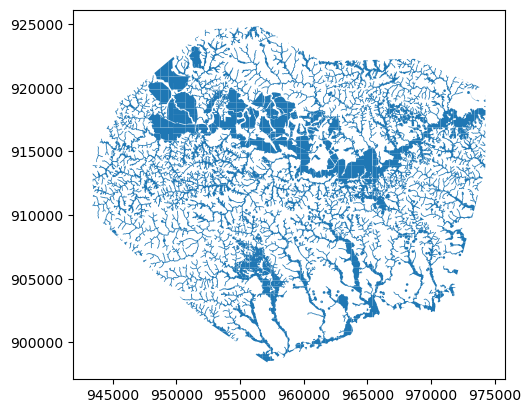

In [44]:
union_filtrada.plot()

In [49]:
import numpy as np
#Agregar campo de cambios y evaluarlo según las condiciones correspondientes
condiciones = [
    (union_filtrada['NOMENCLAT_1'] == 'Exclusión') & (union_filtrada['NOMENCLAT_2'] != 'Exclusión'),
    (union_filtrada['NOMENCLAT_1'] != 'Exclusión') & (union_filtrada['NOMENCLAT_2'] == 'Exclusión'),
    (union_filtrada['NOMENCLAT_1'] == 'Exclusión') & (union_filtrada['NOMENCLAT_2'] == 'Exclusión')
]
valores = ['Disminuye','Aumenta','Se mantiene']
union_filtrada['ZMA_ANTES'] = union_filtrada['NOMENCLAT_1']
union_filtrada['ZMA_AHORA'] = union_filtrada['NOMENCLAT_2']
union_filtrada['CAMBIO_ZMA'] = np.select(condiciones, valores, default='Modificada')

,FID_Zonifi,EXPEDIENTE,ZONMANEJO,NOMENCLAT_1,AREA_HA,OBSERV_1,SHAPE_Leng,Shape_Le_1,Shape_Area,FID_Fishne_1,Id,NOMENCLAT_2,OBSERV_2,FID_Fishne_2,geometry,CAMBIO_ZMA,ZMA_ANTES,ZMA_AHORA
58811,11167.0,LAM0019,5005.0,Exclusión,17935.321000,Exclusión,3.133175e+06,3.132932e+06,1.793752e+08,1014.0,0.0,Con Restricción,Con Restricción,170.0,"POLYGON ((962790.888 918862.781, 962787.956 91...",Disminuye,Exclusión,Con Restricción
53604,11167.0,LAM0019,5005.0,Exclusión,17935.321000,Exclusión,3.133175e+06,3.132932e+06,1.793752e+08,703.0,0.0,Con Restricción,Con Restricción,102.0,"POLYGON ((953741.971 911928.642, 953741.772 91...",Disminuye,Exclusión,Con Restricción
10301,3748.0,LAM0019,0.0,Con Restricción,0.004698,Con Restricción,7.291152e+01,7.291152e+01,4.698401e+01,634.0,0.0,Exclusión,Exclusión,110.0,"POLYGON ((970115.835 910706.133, 970125.095 91...",Aumenta,Con Restricción,Exclusión
21153,7730.0,LAM0019,0.0,Con Restricción,0.046814,Con Restricción,1.300469e+02,1.300469e+02,4.681354e+02,870.0,0.0,Exclusión,Exclusión,131.0,"MULTIPOLYGON (((948010.95 916323.451, 948011.1...",Aumenta,Con Restricción,Exclusión
40449,10967.0,LAM0019,5001.0,Intervención,6685.589519,Intervención,6.652920e+05,6.652920e+05,6.685590e+07,482.0,0.0,Exclusión,Exclusión,66.0,"MULTIPOLYGON (((946920.273 906864.692, 946919....",Aumenta,Intervención,Exclusión
55219,11167.0,LAM0019,5005.0,Exclusión,17935.321000,Exclusión,3.133175e+06,3.132932e+06,1.793752e+08,787.0,0.0,Con Restricción,Con Restricción,116.0,"POLYGON ((951019.67 914358.44, 951019.244 9143...",Disminuye,Exclusión,Con Restricción
23084,8413.0,LAM0019,0.0,Con Restricción,0.060776,Con Restricción,1.924942e+02,1.924942e+02,6.077589e+02,977.0,0.0,Exclusión,Exclusión,157.0,"MULTIPOLYGON (((968870.123 917950.615, 968869....",Aumenta,Con Restricción,Exclusión
36586,10545.0,LAM0019,5001.0,Intervención,1051.332647,Intervención,7.379247e+04,7.379247e+04,1.051333e+07,188.0,0.0,Exclusión,Exclusión,6.0,"POLYGON ((954323.247 900328.533, 954323.725 90...",Aumenta,Intervención,Exclusión
16098,5856.0,LAM0019,0.0,Con Restricción,0.076090,Con Restricción,3.245175e+02,3.245175e+02,7.609014e+02,738.0,0.0,Exclusión,Exclusión,113.0,"MULTIPOLYGON (((944880.836 913244.351, 944880....",Aumenta,Con Restricción,Exclusión
52930,11167.0,LAM0019,5005.0,Exclusión,17935.321000,Exclusión,3.133175e+06,3.132932e+06,1.793752e+08,669.0,0.0,Con Restricción,Con Restricción,106.0,"POLYGON ((961774.831 911093.052, 961774.435 91...",Disminuye,Exclusión,Con Restricción


In [53]:
# Exportar capa resultante a SHP solo con los campos de interés
campos_interes = ['ZMA_ANTES', 'ZMA_AHORA', 'CAMBIO_ZMA', 'geometry']
capa_comp_zma = union_filtrada[campos_interes].copy()
capa_comp_zma = capa_comp_zma.dissolve(by=['ZMA_ANTES', 'ZMA_AHORA', 'CAMBIO_ZMA'], as_index=False)
capa_comp_zma = capa_comp_zma.explode(index_parts=False).reset_index(drop=True)
capa_comp_zma['AREA_ha'] = capa_comp_zma.geometry.area / 10000
capa_comp_zma.to_file(ruta_capa_salida, driver='ESRI Shapefile')

<Axes: >

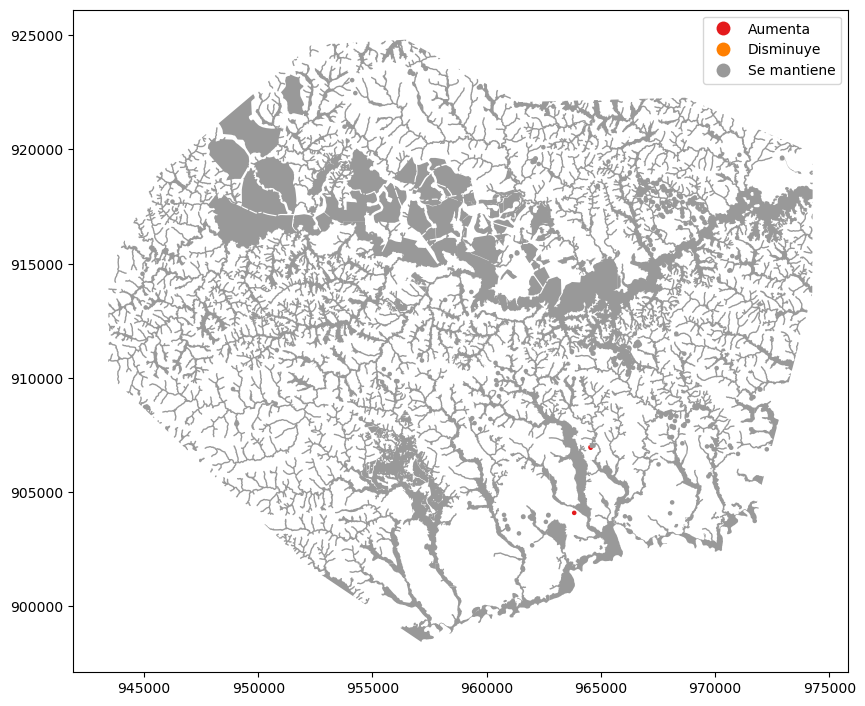

In [56]:
capa_comp_zma.plot(
    column = 'CAMBIO_ZMA',
    cmap='Set1',
    legend=True,
    figsize=(10,10)
)